<a href="https://colab.research.google.com/github/tcmera/tarea-programacion/blob/main/Copia_de_Actividad3_Teresa_Carrion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.listdir("/content")

['.config',
 'malaria_data_final',
 'malaria_final',
 'Malaria.zip',
 'sample_data']

In [ ]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Actividad 3 – Clasificación de datos biomédicos mediante Machine Learning y Deep Learning

## Máster en Bioinformática  
### Programación en Python

**Alumno:** Teresa Carrión Mera  
**Asignatura:** Programación en Python  
**Actividad:** Actividad 3  
**Curso académico:** 2025-2026

---

## Introducción

En esta actividad se desarrollan diferentes modelos de clasificación utilizando técnicas de Machine Learning y Deep Learning.

En primer lugar, se trabaja con el dataset Iris, aplicando distintos algoritmos de clasificación supervisada: Support Vector Machine (SVM), Random Forest y Naive Bayes. Posteriormente, se comparan sus resultados mediante la métrica Accuracy.

En segundo lugar, se implementa una red neuronal convolucional (CNN) para la clasificación de imágenes microscópicas de malaria, diferenciando células parasitadas y no infectadas.

El objetivo principal es aplicar técnicas de inteligencia artificial para resolver problemas biomédicos de clasificación tanto estructurada como basada en imágenes.

## Creación del documento en Google Colab

El documento se ha creado en Google Colab accediendo a la plataforma mediante una cuenta de Google. Se creó un nuevo notebook desde la opción “Nuevo cuaderno”, lo que permitió trabajar en un entorno Python en la nube sin necesidad de instalación local.

Para permitir el acceso a los integrantes del grupo, se utilizó la opción “Compartir” situada en la parte superior derecha del documento. Desde esta opción se pueden añadir los correos electrónicos de los miembros del grupo y asignar permisos de lectura o edición. De este modo, todos los integrantes pueden acceder al documento, revisar el código y colaborar en el desarrollo de la actividad.

## Parte 1 – Clasificación del dataset Iris

El dataset Iris es uno de los conjuntos de datos más utilizados en Machine Learning para problemas de clasificación supervisada. Contiene información sobre diferentes características morfológicas de flores pertenecientes a tres especies distintas de iris.

En esta actividad se aplican distintos algoritmos de clasificación para comparar su rendimiento mediante la métrica Accuracy.

In [ ]:
# Cargar dataset Iris desde Seaborn

iris_df = sns.load_dataset("iris")

iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Separar variables predictoras y variable objetivo

X_iris = iris_df.drop(columns=["species"])
y_iris = iris_df["species"]

# One Hot Encoding de las clases
y_iris_onehot = pd.get_dummies(y_iris)

print(y_iris_onehot.head())

   setosa  versicolor  virginica
0    True       False      False
1    True       False      False
2    True       False      False
3    True       False      False
4    True       False      False


In [ ]:
# División entrenamiento/test

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris,
    y_iris,
    test_size=0.30,
    random_state=42,
    stratify=y_iris
)

print("Forma X_train:", X_train_iris.shape)
print("Forma X_test:", X_test_iris.shape)

Forma X_train: (105, 4)
Forma X_test: (45, 4)


In [ ]:
# Entrenamiento de modelos clásicos

svm_model = SVC()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
nb_model = GaussianNB()

svm_model.fit(X_train_iris, y_train_iris)
rf_model.fit(X_train_iris, y_train_iris)
nb_model.fit(X_train_iris, y_train_iris)

y_pred_svm = svm_model.predict(X_test_iris)
y_pred_rf = rf_model.predict(X_test_iris)
y_pred_nb = nb_model.predict(X_test_iris)

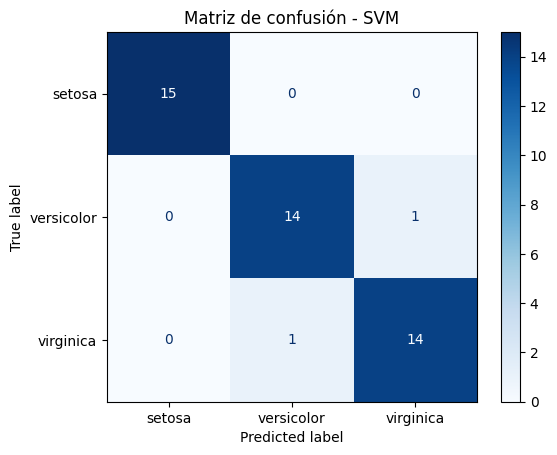

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_iris, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=svm_model.classes_)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - SVM")
plt.show()

In [ ]:
# Métricas: precisión, recall y f1-score

print("SVM")
print(classification_report(y_test_iris, y_pred_svm))

print("Random Forest")
print(classification_report(y_test_iris, y_pred_rf))

print("Naive Bayes")
print(classification_report(y_test_iris, y_pred_nb))

SVM
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45

Naive Bayes
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86  

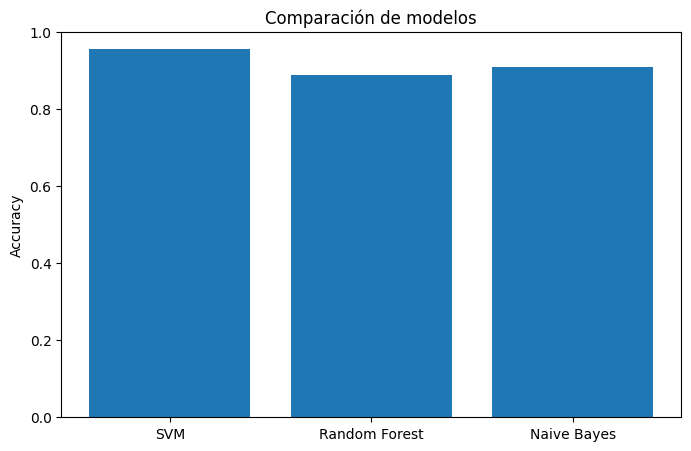

In [ ]:
# Comparación de accuracy

models = ["SVM", "Random Forest", "Naive Bayes"]

accuracies = [
    accuracy_score(y_test_iris, y_pred_svm),
    accuracy_score(y_test_iris, y_pred_rf),
    accuracy_score(y_test_iris, y_pred_nb)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Comparación de modelos")
plt.show()

### Justificación del mejor modelo

A partir de las métricas obtenidas, el modelo SVM presenta el mejor rendimiento global en el conjunto de test. Este modelo alcanza la mayor accuracy y mantiene valores elevados de precision, recall y f1-score.

Random Forest y Naive Bayes también muestran un rendimiento adecuado, aunque ligeramente inferior. Por tanto, en este conjunto de datos, SVM se considera el modelo más adecuado para la clasificación de las especies de Iris.

# Parte 2 – Clasificación de imágenes de malaria mediante Deep Learning

### Justificación de la arquitectura CNN

Se utiliza una red neuronal convolucional porque este tipo de arquitectura es especialmente adecuada para el análisis de imágenes. Las capas convolucionales permiten extraer patrones visuales como bordes, texturas y formas, mientras que las capas de pooling reducen la dimensionalidad y ayudan a conservar la información más relevante.

La capa final utiliza una neurona con activación sigmoid, ya que se trata de un problema de clasificación binaria: células parasitadas frente a células no infectadas.

La función de pérdida seleccionada es binary_crossentropy, adecuada para problemas binarios con salida probabilística.

Se han utilizado tres canales RGB, ya que las imágenes microscópicas contienen información cromática que puede ser útil para diferenciar las células infectadas de las no infectadas.

En esta segunda parte de la actividad se implementa una red neuronal convolucional (CNN) para clasificar imágenes microscópicas de células sanguíneas infectadas y no infectadas por malaria.

Las imágenes pertenecen a dos categorías:

- Parasitized: células infectadas.
- Uninfected: células sanas.

El objetivo es aplicar técnicas de Deep Learning para identificar automáticamente la presencia de malaria a partir de imágenes biomédicas.

In [ ]:
# Descomprimir dataset de malaria

zip_path = "/content/Malaria.zip"

extract_path = "/content/malaria_final"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset descomprimido correctamente")

Dataset descomprimido correctamente


In [ ]:
os.listdir("/content/malaria_final")

['Malaria Data.zip']

In [ ]:
# Descomprimir el ZIP interno

zip_path2 = "/content/malaria_final/Malaria Data.zip"
extract_path2 = "/content/malaria_data_final"

with zipfile.ZipFile(zip_path2, 'r') as zip_ref:
    zip_ref.extractall(extract_path2)

print("Segundo ZIP descomprimido correctamente")

Segundo ZIP descomprimido correctamente


In [ ]:
# Ver carpetas internas reales

os.listdir("/content/malaria_data_final/Malaria")

['Uninfected', 'Parasitized']

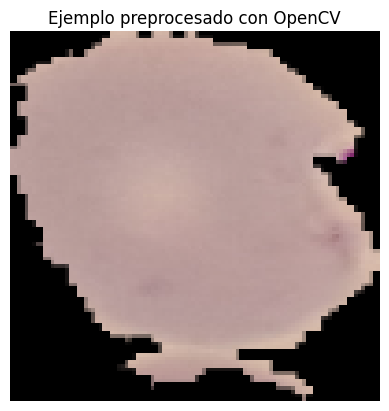

Forma de la imagen: (100, 100, 3)
Rango de valores: 0.0 0.8509803921568627


In [ ]:
# Ejemplo de carga y preprocesamiento con OpenCV

example_path = os.path.join("/content/malaria_data_final/Malaria/Parasitized",
                            os.listdir("/content/malaria_data_final/Malaria/Parasitized")[0])

img = cv2.imread(example_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (100, 100))
img = img / 255.0

plt.imshow(img)
plt.title("Ejemplo preprocesado con OpenCV")
plt.axis("off")
plt.show()

print("Forma de la imagen:", img.shape)
print("Rango de valores:", img.min(), img.max())

Como parte del preprocesamiento se ha utilizado OpenCV para cargar una imagen, convertirla a RGB, redimensionarla a 100x100 píxeles y normalizar sus valores al rango [0,1]. Posteriormente, para optimizar la carga completa del dataset durante el entrenamiento, se ha utilizado ImageDataGenerator de Keras.

In [ ]:
# Generadores de imágenes

from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 64
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "/content/malaria_data_final/Malaria",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "/content/malaria_data_final/Malaria",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [ ]:
# Crear modelo CNN

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(img_size, img_size, 3)),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar modelo CNN

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8037 - loss: 0.4010 - val_accuracy: 0.9354 - val_loss: 0.1730
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 51ms/step - accuracy: 0.9526 - loss: 0.1511 - val_accuracy: 0.9390 - val_loss: 0.1787
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.9559 - loss: 0.1372 - val_accuracy: 0.9448 - val_loss: 0.1602
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9590 - loss: 0.1243 - val_accuracy: 0.9454 - val_loss: 0.1628
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.9614 - loss: 0.1171 - val_accuracy: 0.9446 - val_loss: 0.1576


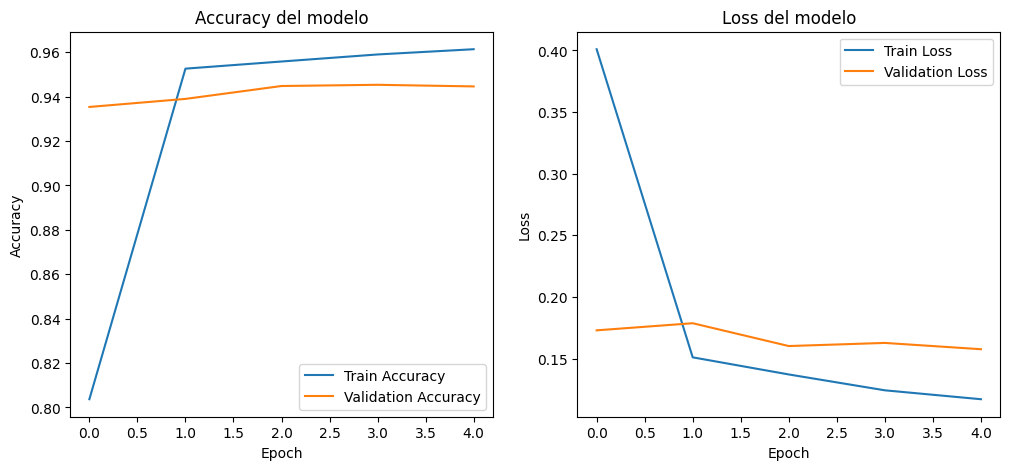

In [ ]:
# Graficar accuracy y loss

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy del modelo')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss del modelo')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluación final en validación

val_loss, val_accuracy = cnn_model.evaluate(val_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9446 - loss: 0.1576
Validation Loss: 0.15764693915843964
Validation Accuracy: 0.9446461200714111


### Interpretación del entrenamiento

Las curvas muestran una mejora progresiva del modelo durante el entrenamiento. La accuracy de validación se mantiene cercana al 95%, mientras que la pérdida de validación permanece baja y estable.

Estos resultados indican que la red neuronal convolucional ha aprendido patrones visuales relevantes para diferenciar células infectadas y no infectadas por malaria, sin evidenciar un sobreajuste importante en esta ejecución.

Conclusiones

En esta actividad se aplicaron diferentes técnicas de Machine Learning y Deep Learning para resolver problemas de clasificación biomédica.

En la primera parte se utilizaron tres algoritmos supervisados sobre el dataset Iris: Support Vector Machine (SVM), Random Forest y Naive Bayes. Los modelos obtuvieron resultados elevados de accuracy, siendo SVM el algoritmo con mejor rendimiento.

Posteriormente, se implementó una red neuronal convolucional (CNN) para la clasificación de imágenes microscópicas de malaria. El modelo fue entrenado utilizando imágenes de células infectadas y no infectadas, alcanzando una accuracy de validación cercana al 95%.

Los resultados obtenidos demuestran la utilidad de las técnicas de inteligencia artificial para la clasificación automática de datos biomédicos, tanto estructurados como basados en imágenes.

Además, se comprobó que las redes neuronales convolucionales son especialmente eficaces para tareas de reconocimiento visual en el ámbito biomédico.

Futuras mejoras podrían incluir técnicas de aumento de datos (data augmentation), ajuste de hiperparámetros y arquitecturas CNN más profundas para optimizar todavía más el rendimiento del modelo.

El uso de técnicas de validación y separación entrenamiento/prueba permitió evaluar adecuadamente la capacidad de generalización de los modelos desarrollados.

### Librerías utilizadas
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- TensorFlow/Keras
- OpenCV